# Linking PG&E utility data with building polygons
This notebook will take Global Building Atlas polygons and link to the nearest PG&E feeder line.

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import box
from shapely.geometry import MultiLineString
import matplotlib.pyplot as plt
import glob
import os
import folium

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
os.environ['PROJ_LIB'] = '/opt/anaconda3/share/proj'

### 1. Read in Data

**PGE line circuit**

In [5]:
pge_circuits = gpd.read_file("../../../../../capstone/electrigrid/data/utilities/pge_shapefiles/LineDetail.shp").to_crs("EPSG:4326")

In [6]:
os.environ['PROJ_LIB'] = '/opt/anaconda3/share/proj'

In [7]:
pge_circuits.head(3)

,FeederId,FeederName,globalid,CSV_LineSe,LoadCapaci,voltage_kv,phase_cnt,limiting_m,limiting_c,ICA_Analys,lica_analy,Division,GenCapacit,GenericPVC,GenCapac_1,GenericCap,limiting_1,limiting_2,limiting_3,limiting_4,limiting_5,limiting_6,limiting_7,limiting_8,ScreenL,Publish,Last_Updat,SHAPE_Leng,geometry
0,062541102,MERIDIAN 1102,{3F991049-BA44-489F-A403-DA79E95B5F6A},3862041,0,12.0,3,None,None,May 2024,May 2024,Sacramento,0,0,0,0,None,None,None,None,None,None,None,None,Unlikely to pass,1,2025-06-02,145.642120,"LINESTRING (-121.95921 39.12370, -121.95951 39..."
1,043302102,MONROE 2102,{65E86C65-2474-4DE9-831A-73C5C6C88469},5458148,2380,21.0,3,None,None,Feb 2025,Feb 2025,Sonoma,60,70,2440,2440,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,9.102052,"LINESTRING (-122.73809 38.48070, -122.73809 38..."
2,063172101,MADISON 2101,{26A0B689-C08B-4AE6-AAC1-341797C5AC4E},3180180,0,21.0,3,None,None,Dec 2024,Dec 2024,Sacramento,0,0,0,0,None,None,None,None,None,None,None,None,Unlikely to pass,1,2025-06-02,4.571886,"LINESTRING (-122.01719 38.69234, -122.01714 38..."


Single family homes (Zillow point data) for Alameda county

In [8]:
alameda_singlefamily = gpd.read_file("../../../../../capstone/electrigrid/data/building_zillow_merges/alamedacounty_building_zillow_merge/non_multi_zillow_alameda.geojson").to_crs("EPSG:4326")
alameda_singlefamily.head(3)

,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,index_right,source,id,height_m,var,region,bbox,area_m2,volume_m3,geometry
0,Multi,2000.0,1.0,None,None,None,40.0,499500.0,living,840.0,403,06001403302,468,PGE/SCE,RR106,2833938,osm,105058335,14.178774,11.995655,USA,"{'xmin': -122.27082929999999, 'ymin': 37.79499...",1424.845227,20202.558291,POINT (-122.27050 37.79521)
1,Multi,1976.0,2.0,None,None,O,53.0,1143597.0,living,1364.0,404,06001403302,468,PGE/SCE,RR106,2833928,osm,350754536,13.578455,5.557640,USA,"{'xmin': -122.2703524, 'ymin': 37.794816499999...",1351.261163,18348.038855,POINT (-122.26979 37.79507)
2,Multi,1976.0,2.0,None,None,O,53.0,831707.0,living,1202.0,405,06001403302,468,PGE/SCE,RR106,2833928,osm,350754536,13.578455,5.557640,USA,"{'xmin': -122.2703524, 'ymin': 37.794816499999...",1351.261163,18348.038855,POINT (-122.26979 37.79507)


Multi-family homes in Alameda county, by parcel (each observation contains the summed number of units in the parcel).

In [9]:
alameda_multifamily = gpd.read_file("../../../../../capstone/electrigrid/data/building_zillow_merges/alamedacounty_building_zillow_merge/multi_summed_units_alameda.geojson").set_crs("EPSG:4326")
alameda_multifamily.head(3)

,PARNO,County,ADDRESS,CITY,ZIP,Shape_Length,Shape_Area,unit,unit_right,geometry
0,48-6331-3-2,Alameda,None,None,None,194.108339,2146.176522,2.0,14.0,"MULTIPOLYGON Z (((-122.11883 37.75180 0.00000,..."
1,45-5419-37,Alameda,None,None,None,103.274358,499.177855,4.0,8.0,"MULTIPOLYGON Z (((-122.17728 37.72609 0.00000,..."
2,48-6231-27-1,Alameda,None,None,None,164.618293,1672.488777,2.0,4.0,"MULTIPOLYGON Z (((-122.12955 37.75105 0.00000,..."


In [10]:
#fig, ax = plt.subplots(figsize=(10, 9))
#pge_linedetail.plot(ax=ax)

Test bbox: -121.977774, 37.324955, -121.879069, 37.375036 (EPSG:4326)

In [11]:
#bbox = box(minx=-121.977774, miny=37.324955, maxx=-121.879069, maxy=37.375036 )
#bbox = gpd.GeoDataFrame(geometry=[bbox], crs=pge_linedetail.crs)

In [12]:
#bbox_circuits = gpd.clip(pge_linedetail, bbox)

In [13]:
#bbox_circuits.head()

In [14]:
#fig, axes = plt.subplots(1, 2, figsize=(15, 5))
#bbox_circuits.plot(ax=axes[0], column='FeederName')
#bbox_circuits.plot(ax=axes[1], column='LoadCapaci')

## Join buildings to circuits (single family homes)

The following plot revealed that Alameda County accounts for only a small part of the PGE territory, so cropping is useful for visualization.

In [15]:
# fig, ax = plt.subplots(figsize=(20, 20))

# ax.axis('off')

# alameda_singlefamily.plot(ax=ax, color='blue')

# pge_circuits.plot(ax=ax, color='red')

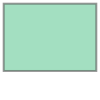

In [16]:
alameda_county_box = box(*alameda_singlefamily.total_bounds)

alameda_county_box

In [17]:
pge_alameda = gpd.clip(pge_circuits, alameda_county_box)

In [18]:
#pge_alameda.columns

<Axes: >

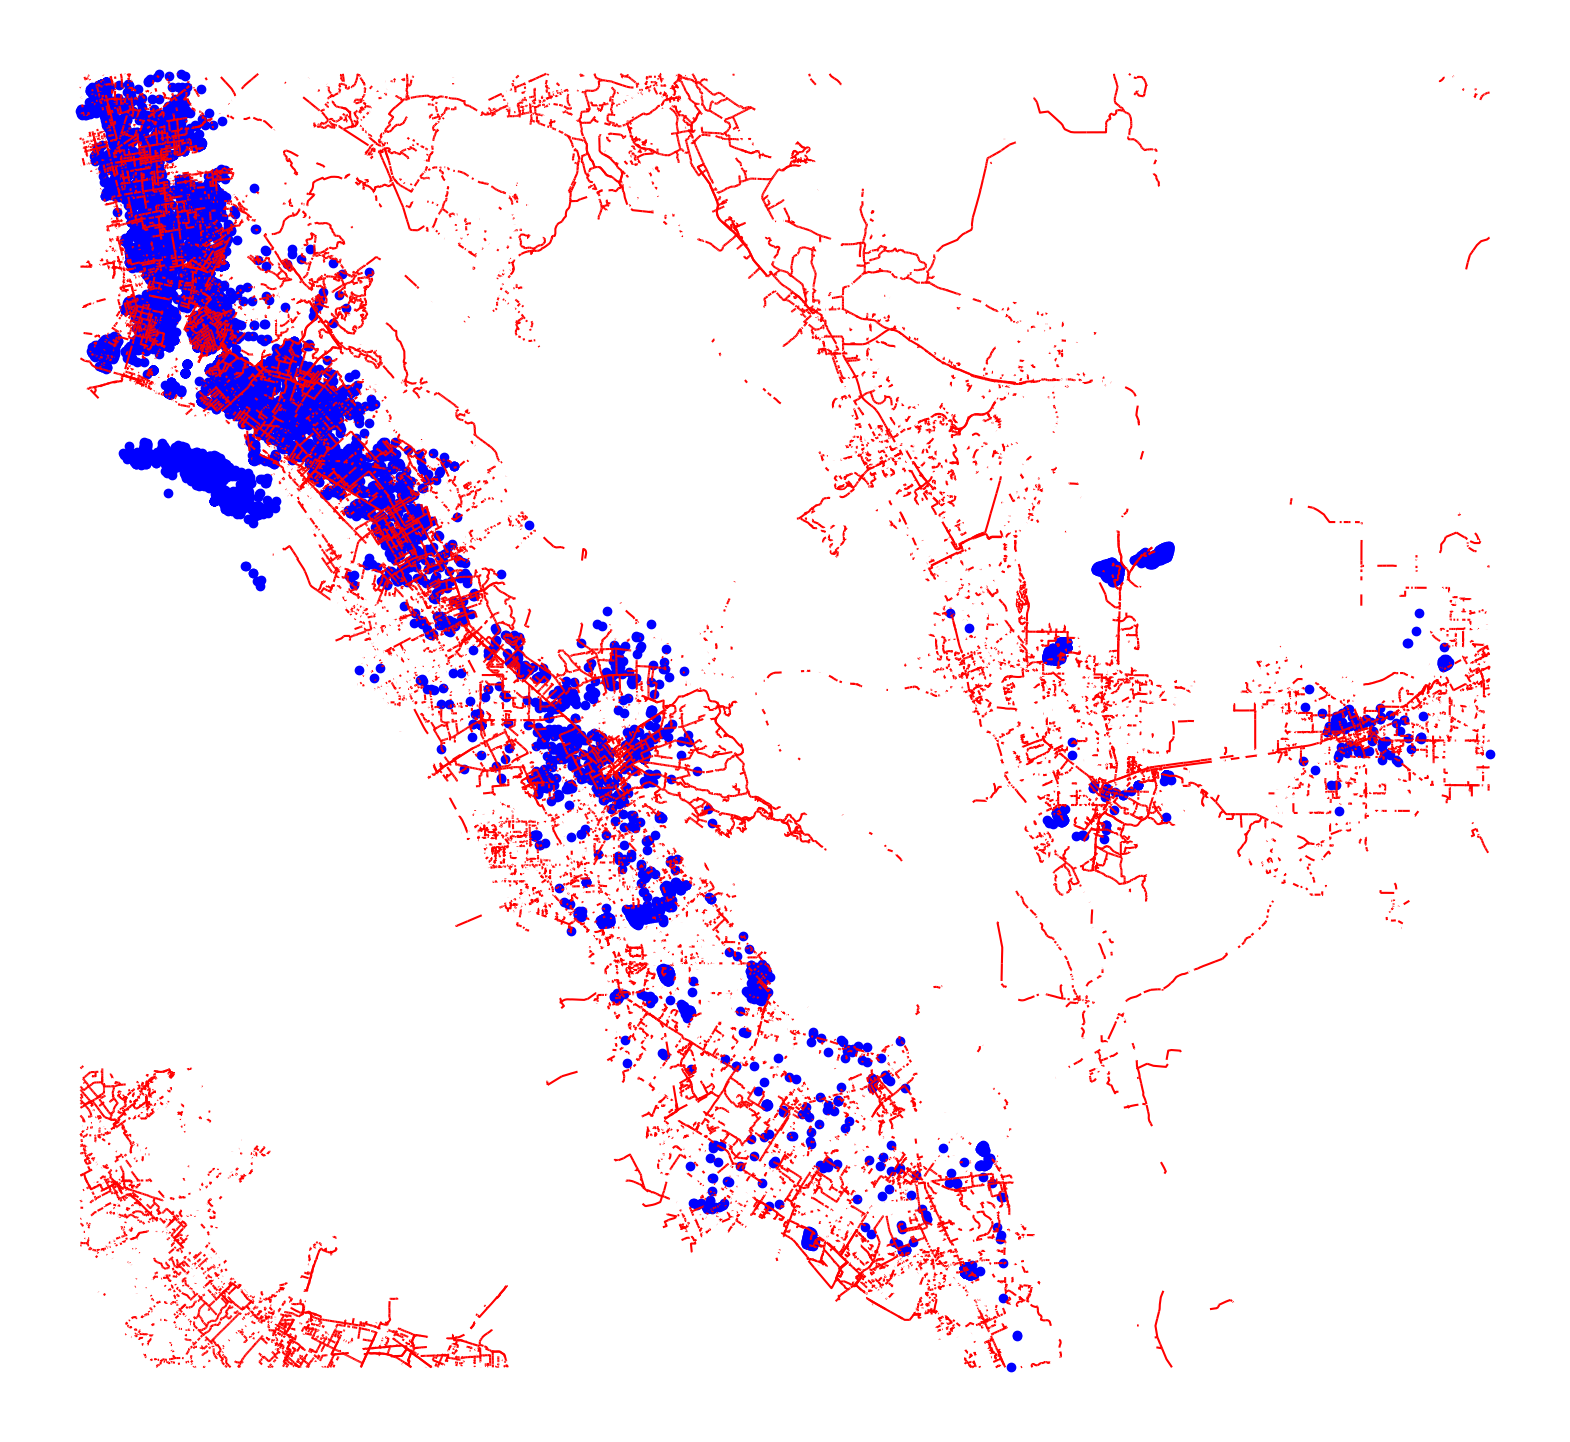

In [19]:
fig, ax = plt.subplots(figsize=(20, 20))

ax.axis('off')

alameda_singlefamily.plot(ax=ax, color='blue')

pge_alameda.plot(ax=ax, color='red')

## Link data

### Single-family homes

In [20]:
# change the crs to a projected CRS
pge_alameda = pge_alameda.to_crs("EPSG:3310")
alameda_singlefamily = alameda_singlefamily.to_crs("EPSG:3310")

# index the data
pge_alameda.sindex
alameda_singlefamily.sindex

# spatial join
alameda_singlefamily_linked = gpd.sjoin_nearest(alameda_singlefamily, 
                                        pge_alameda, 
                                        how="left", 
                                        lsuffix='_left', 
                                        rsuffix='_right',
                                        distance_col='dist_to_line_m')

In [21]:
alameda_singlefamily_linked.head()

,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,index_right,source,id,height_m,var,region,bbox,area_m2,volume_m3,geometry,index__right,FeederId,FeederName,globalid,CSV_LineSe,LoadCapaci,voltage_kv,phase_cnt,limiting_m,limiting_c,ICA_Analys,lica_analy,Division,GenCapacit,GenericPVC,GenCapac_1,GenericCap,limiting_1,limiting_2,limiting_3,limiting_4,limiting_5,limiting_6,limiting_7,limiting_8,ScreenL,Publish,Last_Updat,SHAPE_Leng,dist_to_line_m
0,Multi,2000.0,1.0,None,None,None,40.0,499500.0,living,840.0,403,06001403302,468,PGE/SCE,RR106,2833938,osm,105058335,14.178774,11.995655,USA,"{'xmin': -122.27082929999999, 'ymin': 37.79499...",1424.845227,20202.558291,POINT (-199644.077 -22194.925),444007,012011114,OAKLAND C 1114,{82C12DF7-39F0-44B4-A112-27BA2D955D10},5407066,2580,12.0,3,None,None,Nov 2025,Dec 2024,East Bay,784,1443,784,1443,Safety,4_3,Safety,4_3,Safety,4_3,Safety,4_3,Unlikely to pass,1,2025-12-01,1.826816,28.273568
1,Multi,1976.0,2.0,None,None,O,53.0,1143597.0,living,1364.0,404,06001403302,468,PGE/SCE,RR106,2833928,osm,350754536,13.578455,5.557640,USA,"{'xmin': -122.2703524, 'ymin': 37.794816499999...",1351.261163,18348.038855,POINT (-199582.109 -22211.532),186852,012011115,OAKLAND C 1115,{4DC1D5B2-E5A8-40B9-A8D7-37A3B67CE12C},5040177,1230,12.0,3,None,None,Nov 2025,Jan 2025,East Bay,652,1186,652,1186,Safety,4_3,Safety,4_3,Safety,4_3,Safety,4_3,Unlikely to pass,1,2025-12-01,33.006969,7.739014
2,Multi,1976.0,2.0,None,None,O,53.0,831707.0,living,1202.0,405,06001403302,468,PGE/SCE,RR106,2833928,osm,350754536,13.578455,5.557640,USA,"{'xmin': -122.2703524, 'ymin': 37.794816499999...",1351.261163,18348.038855,POINT (-199582.109 -22211.532),186852,012011115,OAKLAND C 1115,{4DC1D5B2-E5A8-40B9-A8D7-37A3B67CE12C},5040177,1230,12.0,3,None,None,Nov 2025,Jan 2025,East Bay,652,1186,652,1186,Safety,4_3,Safety,4_3,Safety,4_3,Safety,4_3,Unlikely to pass,1,2025-12-01,33.006969,7.739014
3,Multi,1976.0,2.0,None,None,None,53.0,1064863.0,living,1349.0,406,06001403302,468,PGE/SCE,RR106,2833928,osm,350754536,13.578455,5.557640,USA,"{'xmin': -122.2703524, 'ymin': 37.794816499999...",1351.261163,18348.038855,POINT (-199582.109 -22211.532),186852,012011115,OAKLAND C 1115,{4DC1D5B2-E5A8-40B9-A8D7-37A3B67CE12C},5040177,1230,12.0,3,None,None,Nov 2025,Jan 2025,East Bay,652,1186,652,1186,Safety,4_3,Safety,4_3,Safety,4_3,Safety,4_3,Unlikely to pass,1,2025-12-01,33.006969,7.739014
4,Multi,1976.0,2.0,None,None,None,53.0,1150000.0,living,1309.0,407,06001403302,468,PGE/SCE,RR106,2833928,osm,350754536,13.578455,5.557640,USA,"{'xmin': -122.2703524, 'ymin': 37.794816499999...",1351.261163,18348.038855,POINT (-199582.109 -22211.532),186852,012011115,OAKLAND C 1115,{4DC1D5B2-E5A8-40B9-A8D7-37A3B67CE12C},5040177,1230,12.0,3,None,None,Nov 2025,Jan 2025,East Bay,652,1186,652,1186,Safety,4_3,Safety,4_3,Safety,4_3,Safety,4_3,Unlikely to pass,1,2025-12-01,33.006969,7.739014


In [22]:
print(alameda_singlefamily_linked['dist_to_line_m'].min())
print(alameda_singlefamily_linked['dist_to_line_m'].max())

1.8540218257251158
2963.9728855007224


#### Link multi-family homes

In [23]:
alameda_multifamily = alameda_multifamily.to_crs("EPSG:3310")

# index the data
alameda_multifamily.sindex

# spatial join
alameda_multifamily_linked = gpd.sjoin_nearest(alameda_multifamily, 
                                        pge_alameda, 
                                        how="left", 
                                        lsuffix='_left', 
                                        rsuffix='_right',
                                        distance_col='dist_to_line_m')

In [24]:
alameda_multifamily_linked.head()

,PARNO,County,ADDRESS,CITY,ZIP,Shape_Length,Shape_Area,unit,unit_right,geometry,index__right,FeederId,FeederName,globalid,CSV_LineSe,LoadCapaci,voltage_kv,phase_cnt,limiting_m,limiting_c,ICA_Analys,lica_analy,Division,GenCapacit,GenericPVC,GenCapac_1,GenericCap,limiting_1,limiting_2,limiting_3,limiting_4,limiting_5,limiting_6,limiting_7,limiting_8,ScreenL,Publish,Last_Updat,SHAPE_Leng,dist_to_line_m
0,48-6331-3-2,Alameda,None,None,None,194.108339,2146.176522,2.0,14.0,MULTIPOLYGON Z (((-186418.036 -27327.606 0.000...,177235,013111109,SAN LEANDRO U 1109,{4AF060D1-FFFA-47CC-9437-F783680CD1C9},3597648,0,12.0,3,None,None,Dec 2024,Nov 2025,Mission,0,0,390,580,None,None,None,None,None,None,None,None,Data Not Available,1,2025-12-01,75.800426,199.665842
0,48-6331-3-2,Alameda,None,None,None,194.108339,2146.176522,2.0,14.0,MULTIPOLYGON Z (((-186418.036 -27327.606 0.000...,21033,013111109,SAN LEANDRO U 1109,{32F17F0F-FBD2-474A-A9BD-BECF76D446BE},5005553,0,12.0,3,None,None,Dec 2024,Nov 2025,Mission,0,0,390,570,None,None,None,None,None,None,None,None,Data Not Available,1,2025-12-01,45.790905,199.665842
1,45-5419-37,Alameda,None,None,None,103.274358,499.177855,4.0,8.0,MULTIPOLYGON Z (((-191625.385 -30069.116 0.000...,320146,013681103,EDES 1103,{A9601F70-4100-47F0-B8D6-2C420DDC2E92},3990819,290,12.0,3,None,None,Jan 2025,Jan 2025,East Bay,190,280,270,330,None,None,None,None,None,None,None,None,Data Not Available,1,2025-06-02,4.571967,195.361609
2,48-6231-27-1,Alameda,None,None,None,164.618293,1672.488777,2.0,4.0,MULTIPOLYGON Z (((-187362.733 -27390.091 0.000...,654315,013111109,SAN LEANDRO U 1109,{8CBDC9A4-1C50-45B1-B581-20F13906C102},3203417,0,12.0,3,None,None,Dec 2024,Nov 2025,Mission,0,0,740,1090,None,None,None,None,None,None,None,None,Data Not Available,1,2025-12-01,77.342455,150.508878
2,48-6231-27-1,Alameda,None,None,None,164.618293,1672.488777,2.0,4.0,MULTIPOLYGON Z (((-187362.733 -27390.091 0.000...,666066,013111109,SAN LEANDRO U 1109,{9BEE70EA-3A3F-4846-8C57-E2F457EC3905},3116274,0,12.0,3,None,None,Dec 2024,Nov 2025,Mission,0,0,740,1090,None,None,None,None,None,None,None,None,Data Not Available,1,2025-12-01,19.631488,150.508878


In [25]:
print(alameda_multifamily_linked['dist_to_line_m'].min())
print(alameda_multifamily_linked['dist_to_line_m'].max())

0.0
3000.0335421935147


In [38]:
# Filter for homes that are within 1000m of a feederline
multi_morethan1k = len(alameda_multifamily_linked[alameda_multifamily_linked['dist_to_line_m'] >= 1000])
multi_all = len(alameda_multifamily_linked)

single_morethan1k = len(alameda_singlefamily_linked[alameda_singlefamily_linked['dist_to_line_m'] >= 1000])
single_all = len(alameda_singlefamily_linked)

In [49]:
print(f"{round(multi_morethan1k/multi_all, 2)*100}% of multi-family homes are outliers")
print(f"{round(single_morethan1k/single_all, 2)*100}% of single-family homes are outliers")

6.0% of multi-family homes are outliers
5.0% of single-family homes are outliers


## Visual Check

Single-family homes

In [ ]:
fig, ax = plt.subplots(figsize=(20, 20))

ax.axis('off')

alameda_singlefamily_linked.plot(ax=ax, column='FeederId')

pge_alameda.plot(ax=ax, column='FeederId')

Multi-family homes

In [ ]:
fig, ax = plt.subplots(figsize=(20, 20))

ax.axis('off')

alameda_multifamily_linked.plot(ax=ax, column='FeederId')

pge_alameda.plot(ax=ax, column='FeederId')

## Plot data interactively for ML labeling (incomplete)

In [ ]:
# # Initilize folium map with specified center location
# m = folium.Map(location=(37.6017, -121.7195), zoom_start=12)

# circuit_popup = folium.GeoJsonPopup(fields=['CSV_LineSe', 'LoadCapaci'])

# # Census layer
# #folium.GeoJson(data=la_census,
#                #style_function=lambda feature: {"fillColor":"gray", "color":"black"}).add_to(m)

# # Buildings layer
# folium.GeoJson(data=alameda_buildings,
#                style_function=lambda feature: {"color":"red"}).add_to(m)

# # Circuits layer
# folium.GeoJson(data=pge_circuits, popup=circuit_popup, highlight_function=lambda feature: {"color":"orange"}).add_to(m)

# display(m)

In [ ]:
# print(alameda_buildings.crs)
# print(pge_circuits.crs)
# print(alameda_buildings.total_bounds)

In [ ]:
# # Define conditions and choices
# conditions = [
#     pge_circuits['CSV_LineSe'].isin(['A', 'C']),
#     pge_circuits['CSV_LineSe'].isin(['A', 'C'])
# ]
# choices = ['feeder', 'trunk']

# pge_circuits['segment_class'] = np.select(conditions, choices, default='other')